# Metodologia em Árvore
Foi escolhido a metodologia em árvore para treinar o modelo. Utilizamos a **entropia** como critério para modelagem da árvore, sendo avaiado o ganho de informação de cada atributo.

## Importação de bibliotecas
Foi realizado o import das bibliotecas pandas, numpy, matplotlib e sklean, para realizar o tratamento dos dados, plotagem e o treinamento do modelo de aprendizado de máquina.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Importação do dataset
Foi realizado a importação do dataset Heart Failure Prediction Dataset disponível no Kaggle.

In [ ]:
try:
  df = pd.read_csv('heart.csv')
  display(df.head())
except FileNotFoundError:
  print('Erro: falha ao abrir')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Transformação dos dados
As colunas textuais categóricas (Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope) foram convertidas em valores numéricos utilizando a classe LabelEncoder, visto que a implementação da árvore de decisão no Scikit-learn requer matrizes numéricas.

In [ ]:
encoder = LabelEncoder()
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

if 'df' in locals():
    for col in categorical_cols:
        df[col] = encoder.fit_transform(df[col])
    display(df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


## Separação dos dados em Treino vs Teste
Separação do dataset na proporção de 80% dos dados para treinamento e 20% para teste utilizando train_test_split, garantindo que o modelo seja avaliado em dados não vistos por ele na etapa de aprendizado.

In [ ]:
if 'df' in locals():
    X = df.drop(columns=['HeartDisease'])
    y = df['HeartDisease']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f'Tamanho do conjunto de treino: {X_train.shape[0]} amostras')
    print(f'Tamanho do conjunto de teste: {X_test.shape[0]} amostras')

Tamanho do conjunto de treino: 752 amostras
Tamanho do conjunto de teste: 166 amostras


## Treinamento do modelo
Foi instanciado um modelo *DecisionTreeClassifier* com o critério configurado para *entropy*, com uma profundidade máxima (*max_depth=*4) para auxiliar na generalização do modelo e evitar *overfitting*.

In [ ]:
if 'df' in locals():
  tree_clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
  tree_clf.fit(X_train, y_train)
  print('Treinado com sucesso"!')

Treinado com sucesso"!


## Cálculo de métricas
Foi realizado o cálculo das métricas de acurácia, precisão, recall e F1.

In [ ]:
if 'df' in locals():
  y_pred = tree_clf.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  print(f'\n---Acurácia---')
  print(f'{accuracy * 100:.2f}%')

  print(f'\n---Relatorio de Classificação---')
  print(classification_report(y_test, y_pred))


---Acurácia---
87.35%

---Relatorio de Classificação---
              precision    recall  f1-score   support

           0       0.85      0.86      0.85        70
           1       0.89      0.89      0.89        96

    accuracy                           0.87       166
   macro avg       0.87      0.87      0.87       166
weighted avg       0.87      0.87      0.87       166



## Validação Cruzada k-Fold

Para avaliar a consistência do modelo e sua generalização, será utilizada a validação cruzada k-fold com 5 divisões. Isso ajuda a reduzir o viés da divisão treino/teste e fornece uma estimativa mais robusta do desempenho do modelo.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

if 'df' in locals():
    k = 5

    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    cv_scores = cross_val_score(tree_clf, X, y, cv=kf, scoring='accuracy')

    print(f'Pontuações de Acurácia da Validação Cruzada ({k}-Fold):\n{cv_scores}')
    print(f'Média das Pontuações de Acurácia: {cv_scores.mean():.4f}')
    print(f'Desvio Padrão das Pontuações de Acurácia: {cv_scores.std():.4f}')


Pontuações de Acurácia da Validação Cruzada (5-Fold):
[0.86956522 0.8423913  0.8423913  0.81420765 0.82513661]
Média das Pontuações de Acurácia: 0.8387
Desvio Padrão das Pontuações de Acurácia: 0.0188


## Matriz de Confusão
Plotagem da matriz de confusão para ter uma interpretação visual.

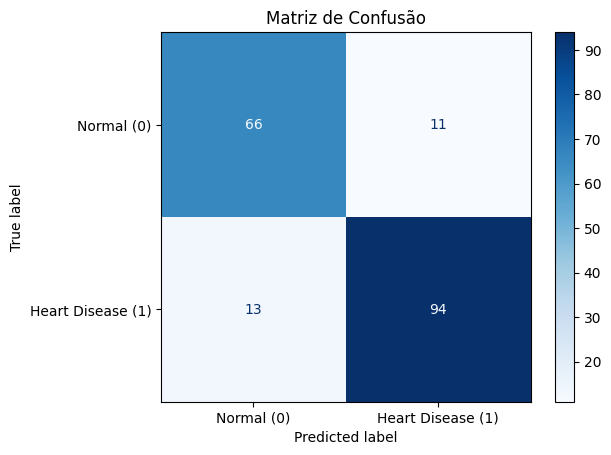

In [ ]:
if 'df' in locals():
    cm = confusion_matrix(y_test, y_pred, labels=tree_clf.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Heart Disease (1)'])
    disp.plot(cmap='Blues')
    plt.title('Matriz de Confusão')
    plt.show()

## Visualização da Árvore
Plotagem da árvore de decisão criado pelo modelo, bem como os parâmetros, a quantidade de dados naquele nó, entropia, etc.

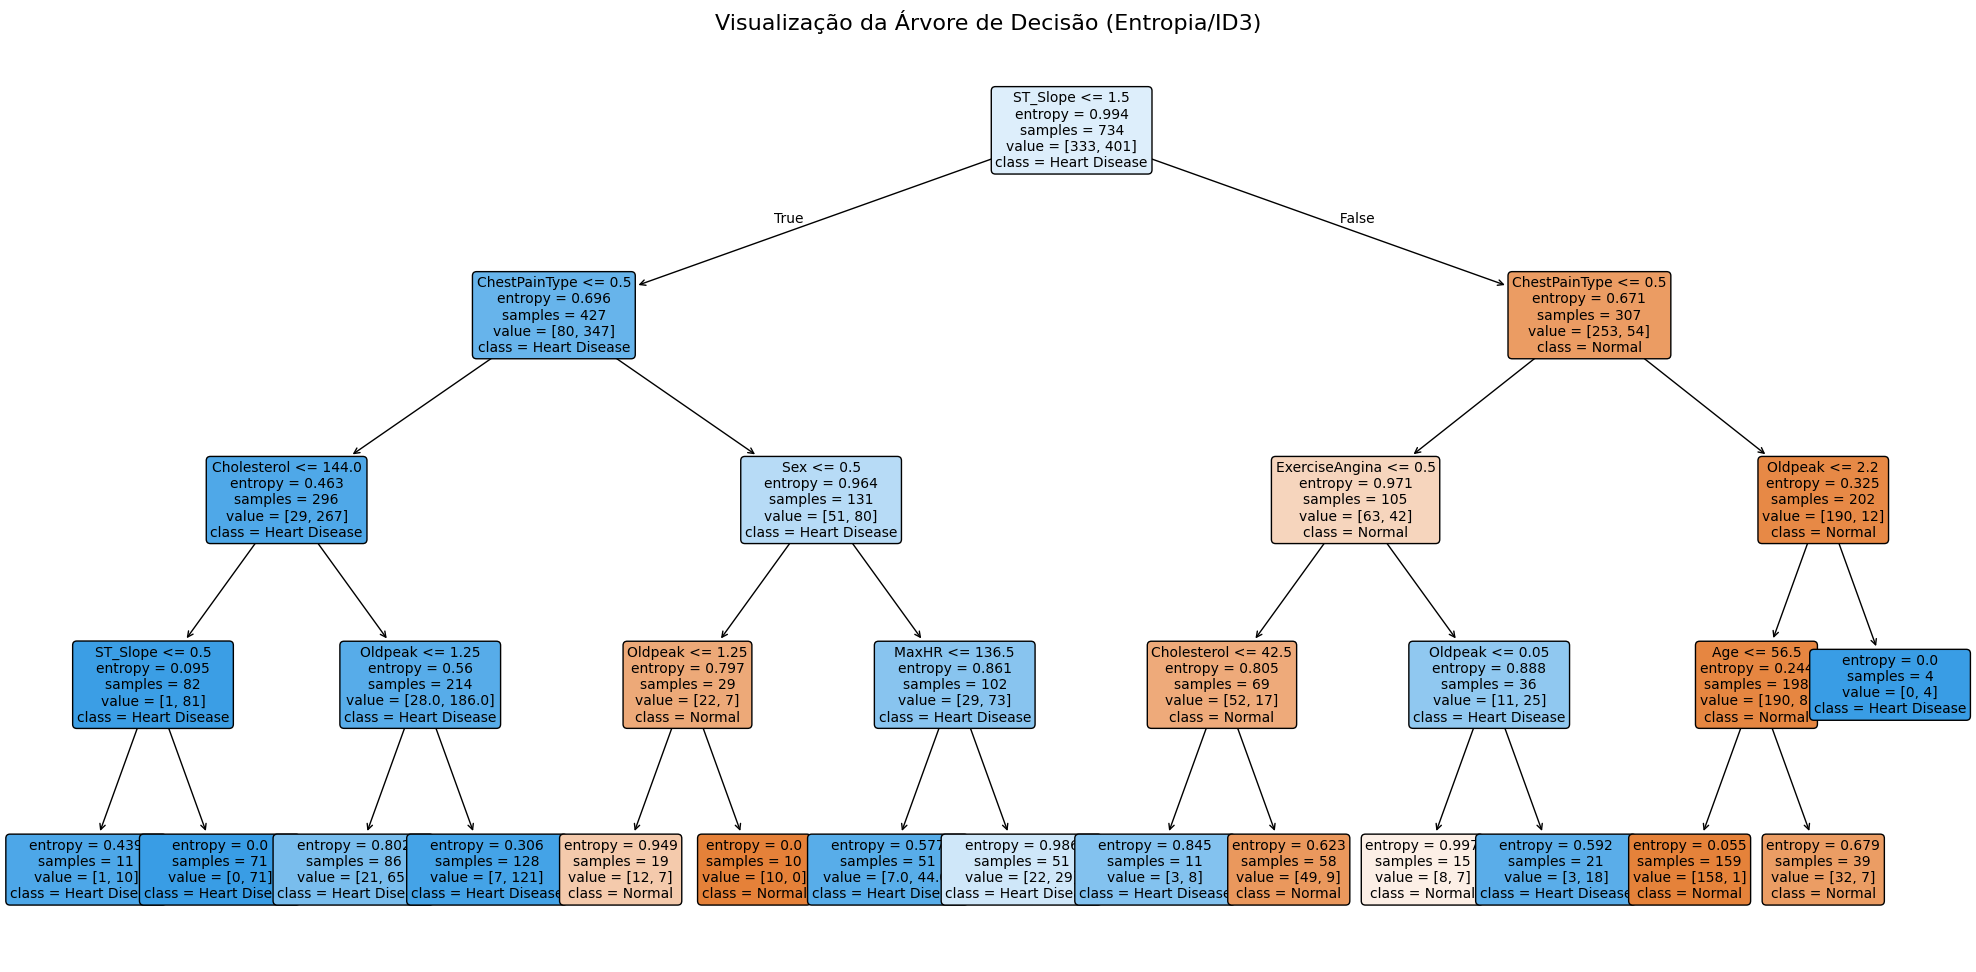

In [ ]:
if 'df' in locals():
    plt.figure(figsize=(25, 12))
    plot_tree(
        tree_clf,
        feature_names=list(X.columns),
        class_names=['Normal', 'Heart Disease'],
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title("Visualização da Árvore de Decisão (Entropia/ID3)", fontsize=16)
    plt.show()